[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap08/cap08_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:19%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 8 Compreendendo Cenas: Correspondência de Características, Detecção e Segmentação

No **Capítulo 7**, foi estudado como representar imagens por meio de descritores e utilizar essas representações para tarefas de classificação. Neste capítulo, o problema é ampliado: além de reconhecer padrões, torna-se necessário estabelecer correspondências entre diferentes imagens, localizar automaticamente objetos de interesse e interpretar a organização espacial de uma cena.

Esses problemas constituem algumas das principais tarefas da Visão Computacional e representam uma etapa natural após a classificação de imagens. Para resolvê-los, serão apresentados métodos clássicos de correspondência de características, detecção de objetos e segmentação de imagens, bem como uma visão geral das abordagens modernas baseadas em *Deep Learning*, preparando a transição para o **Capítulo 9**.

## 8.1 Objetivos do Capítulo

Ao concluir este capítulo, o estudante deverá ser capaz de:

- **Estabelecer correspondências entre imagens** utilizando detectores e descritores locais, estimando transformações geométricas por meio de homografias;
- **Localizar objetos de interesse** em imagens utilizando métodos clássicos de detecção e avaliar os resultados por meio de métricas como ***Intersection over Union* (IoU)** e ***Non-Maximum Suppression* (NMS)**;
- **Diferenciar os paradigmas de segmentação** — semântica, de instâncias e panóptica — e aplicar métodos clássicos de segmentação;
- **Extrair descritores geométricos e topológicos** de objetos segmentados e exportá-los como anotações estruturadas (CSV ou formato YOLO), validando-as por meio da métrica IoU;
- **Relacionar os métodos clássicos de correspondência, detecção e segmentação** com as abordagens modernas baseadas em *Deep Learning*, estudadas no **Capítulo 9**.

## 8.2 Configuração do Ambiente

In [61]:
import importlib
import subprocess
import sys

for mod, pkg in {
    "cv2": "opencv-python",
    "skimage": "scikit-image",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import cv2
import numpy as np
import importlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import data as skdata
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.morphology import remove_small_objects, opening, disk

import os
import urllib.request

if not os.path.exists("morph.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/morph.py",
        "morph.py",
    )

import morph
importlib.reload(morph); 
from morph import mm

print(f"✅ Ambiente pronto. morph {getattr(morph, '__version__', 'local_file')}")

✅ Ambiente pronto. morph 1.1.5


## 8.3 Detectores e Descritores Locais de Características

No capítulo anterior, cada imagem foi representada por um único vetor de características utilizado para classificação. Em diversas aplicações, entretanto, é necessário comparar apenas partes da imagem, estabelecendo correspondências entre regiões observadas em diferentes instantes, posições ou pontos de vista. Essa tarefa requer uma representação local da imagem, capaz de identificar estruturas suficientemente distintas para serem reencontradas em outras imagens.

Esse processo é realizado em duas etapas complementares. Inicialmente, um **detector** identifica pontos de interesse (*keypoints*), normalmente associados a cantos ou regiões com variações significativas de intensidade. Em seguida, um **descritor** representa numericamente a vizinhança de cada ponto detectado, permitindo comparar regiões correspondentes entre diferentes imagens.

Uma vez obtidos os pares *(ponto, descritor)*, a correspondência (*matching*) consiste em encontrar, para cada descritor de uma imagem, o descritor mais semelhante na outra. Essas correspondências constituem a base de diversas aplicações, como registro de imagens, reconstrução tridimensional, navegação visual e realidade aumentada.

### 8.3.1 O Algoritmo ORB (*Oriented FAST and Rotated BRIEF*)

Neste capítulo será utilizado o **ORB**, um detector e descritor local que combina eficiência computacional e robustez a rotações. O algoritmo reúne três componentes principais:

- **FAST** (*Features from Accelerated Segment Test*), responsável pela detecção dos pontos-chave;
- **BRIEF** (*Binary Robust Independent Elementary Features*), responsável pela construção do descritor binário;
- um mecanismo de **estimativa de orientação**, que torna o descritor aproximadamente invariante à rotação.

O detector **FAST** percorre todos os pixels da imagem. Para cada pixel candidato, analisa um círculo de **16 pixels** ao seu redor. Se um conjunto de pixels consecutivos apresentar intensidade significativamente maior ou menor que a intensidade do pixel central, esse pixel é considerado um **ponto-chave** (*keypoint*). Em seguida, candidatos muito próximos são filtrados, preservando apenas os mais representativos.

Após a detecção dos pontos-chave, o descritor **BRIEF** é calculado em uma vizinhança ao redor de cada ponto-chave, e não apenas sobre os 16 pixels utilizados pelo FAST. Nessa região, um conjunto fixo de pares de pontos $(x,y)$ é comparado segundo a [Equação 8.1](#eq-brief). No ORB, esse padrão de amostragem é rotacionado de acordo com a orientação estimada do ponto-chave, reduzindo a sensibilidade à rotação.

<a id="eq-brief"></a>
$$
\tau(p;x,y)=
\begin{cases}
1,& \text{se } I(x)<I(y),\\
0,& \text{caso contrário},
\end{cases} \tag{8.1}
$$


em que:

- $p$ é o ponto-chave detectado pelo FAST;
- $x$ e $y$ são dois pontos da vizinhança de $p$, escolhidos pelo padrão de amostragem do BRIEF;
- $I(\cdot)$ representa a intensidade de um pixel;
- $\tau(p;x,y)$ é o resultado da comparação binária entre os pontos $x$ e $y$.

A sequência dos bits produzidos por essas comparações constitui o descritor do ponto-chave.

Como o descritor é binário, a similaridade entre dois pontos é medida pela **distância de Hamming**, correspondente ao número de bits diferentes entre dois descritores. Essa métrica pode ser calculada de forma muito eficiente por operações lógicas sobre os bits, tornando o ORB adequado para aplicações em tempo real.


### 8.3.2 Explorando o Simulador do ORB

A [Figura 8.2](#fig-08-sim-orb) ilustra, de forma interativa, como o descritor **ORB** é construído. Cada segmento representa um dos pares de pontos $(x,y)$ utilizados na [Equação 8.1](#eq-brief). As comparações produzem a sequência de bits que constitui o descritor do ponto-chave.

Inicialmente, compare a imagem original com a mesma imagem rotacionada em **15°**, mantendo o ruído igual a zero:

```text
0°  : 00000000000000100000011111100010
15° : 00000000000000100000011111100010
```

Nesse exemplo, ambos os descritores são idênticos, mostrando que a estimativa de orientação reduz os efeitos da rotação.

Em seguida, adicione ruído e repita o experimento:

```text
0°  : 01000000001000110110011111101010
15° : 10110000001011100100111111100010
```

O ruído altera parte das comparações de intensidade, modificando alguns bits do descritor. A diferença entre dois descritores é medida pela **distância de Hamming**, correspondente ao número de posições em que os bits diferem. Para os descritores acima, essa distância é igual a **10**.

Uma forma eficiente de calcular essa distância em Python consiste em aplicar a operação **XOR** (`^`), que identifica os bits diferentes, seguida do método `bit_count()`, que contabiliza quantos bits iguais a 1 existem no resultado.

In [62]:
def hamming(a: int, b: int) -> int:
    return (a ^ b).bit_count()
a = 0b01000000001000110110011111101010
b = 0b10110000001011100100111111100010
hamming(a, b)

10

A [Figura 8.1](#fig-08-hamming-benchmark) compara essa implementação com uma versão baseada na comparação de caracteres e com a implementação otimizada do OpenCV (`cv2.NORM_HAMMING`).

            Método  Tempo (s)  Speedup
0          Strings   3.147249      1.0
1  XOR+bit_count()   0.032726     96.2
2           OpenCV   0.419861      7.5


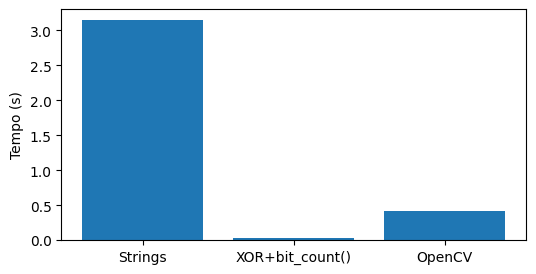

**Figura 8.1:** Comparação do desempenho de diferentes implementações da distância de Hamming.


In [63]:
import random, timeit, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt

BITS, N = 256, 100_000
A = [''.join(random.choice('01') for _ in range(BITS)) for _ in range(N)]
B = [''.join(random.choice('01') for _ in range(BITS)) for _ in range(N)]
Ai, Bi = map(lambda L: [int(x,2) for x in L], (A,B))
Acv = np.array([[int(s[i:i+8],2) for i in range(0,BITS,8)] for s in A], np.uint8)
Bcv = np.array([[int(s[i:i+8],2) for i in range(0,BITS,8)] for s in B], np.uint8)

H = [
    ("Strings", lambda: sum(sum(x!=y for x,y in zip(a,b)) for a,b in zip(A,B))),
    ("XOR+bit_count()", lambda: sum((a^b).bit_count() for a,b in zip(Ai,Bi))),
    ("OpenCV", lambda: sum(cv2.norm(a,b,cv2.NORM_HAMMING) for a,b in zip(Acv,Bcv)))
]

df = pd.DataFrame(
    [(n, timeit.timeit(f, number=1)) for n,f in H],
    columns=["Método","Tempo (s)"]
)
df["Speedup"] = (df.iloc[0,1]/df["Tempo (s)"]).round(1)

print(df)

plt.figure(figsize=(6,3))
plt.bar(df["Método"], df["Tempo (s)"])
plt.ylabel("Tempo (s)")
plt.show()

In [64]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="orb8_Root">
<style>
  #orb8_Root * { box-sizing: border-box; }
  #orb8_Root { font-family: sans-serif; padding: 10px; max-width: 760px; margin: 0 auto; color: #374151; }
  #orb8_Root canvas { display: block; border-radius: 6px; border: 1px solid #d1d5db; background: #111827; margin: 0 auto; }
  #orb8_Root button { font-size: 11px; padding: 6px 12px; border-radius: 4px; border: 1px solid #d1d5db; background: #fff; color: #374151; cursor: pointer; transition: background 0.15s; }
  #orb8_Root button:hover { background: #f3f4f6; }
  #orb8_Root button.orb8_active { background: #4f46e5; color: #fff; border-color: #4f46e5; }
  #orb8_Root input[type=range] { width: 100%; accent-color: #6366f1; }
  .orb8_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .orb8_row { display: flex; align-items: center; gap: 10px; flex-wrap: wrap; }
  .orb8_stat { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px 14px; text-align: center; min-width: 90px; }
  .orb8_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 2px; }
  .orb8_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; color: #4f46e5; }
  .orb8_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #a5b4fc; background: #eef2ff; color: #4338ca; }
  .orb8_legend { display: flex; align-items: center; gap: 6px; font-size: 11px; }
  .orb8_dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; border: 1px solid rgba(0,0,0,0.2); }
  .orb8_bitstream { font-family: monospace; word-break: break-all; background: #1f2937; color: #10b981; padding: 8px; border-radius: 4px; font-size: 11px; max-height: 50px; overflow-y: auto; text-shadow: 0 0 2px rgba(16,185,129,0.5); }
</style>

<div class="orb8_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">🎯 Simulador Interativo: Alinhamento de Orientação e BRIEF (ORB)</span>
  <span class="orb8_pill">Invariância de Orientação em Tempo Real</span>
</div>

<div class="orb8_panel">
  <div class="orb8_row" style="margin-bottom:8px;">
    <div class="orb8_stat"><div class="orb8_stat_label">Ângulo (θ)</div><div id="orb8_angVal" class="orb8_stat_value">0°</div></div>
    <div class="orb8_stat"><div class="orb8_stat_label">Dist. Hamming</div><div id="orb8_hammVal" class="orb8_stat_value">0</div></div>
    <div class="orb8_stat"><div class="orb8_stat_label">Pares Ativos</div><div id="orb8_pairsVal" class="orb8_stat_value">32</div></div>
    <button id="orb8_btnRot">Girar +15°</button>
    <button id="orb8_btnReset">Resetar Ângulo</button>
    <button id="orb8_btnNoise">Adicionar Ruído</button>
  </div>
  <label style="font-size:11px;font-weight:600;color:#374151;">Ângulo de Rotação Aplicado à Imagem: <span id="orb8_slVal">0</span>°</label>
  <input type="range" id="orb8_slider" min="-180" max="180" step="5" value="0">
</div>

<canvas id="orb8_canvas" width="640" height="340"></canvas>

<div class="orb8_panel" style="margin-top:10px;">
  <div style="font-size:11px; font-weight:600; color:#374151; margin-bottom:4px;">Assinatura do Descritor Binário Gerada (BRIEF 32-bits):</div>
  <div id="orb8_bits" class="orb8_bitstream">00000000000000000000000000000000</div>
  <div class="orb8_row" style="justify-content:space-between; margin-top:8px;">
    <div class="orb8_legend"><span style="width:12px; height:2px; background:#10b981; display:inline-block;"></span> Teste = 1 (I(A) &lt; I(B))</div>
    <div class="orb8_legend"><span style="width:12px; height:2px; background:#ef4444; display:inline-block;"></span> Teste = 0 (I(A) ≥ I(B))</div>
    <div style="font-size:11px;color:#6b7280;">A linha amarela indica o vetor centroide da orientação estimada.</div>
  </div>
</div>
</div>

<script>
(function(){
  const canvas = document.getElementById("orb8_canvas");
  const ctx = canvas.getContext("2d");
  const W = canvas.width, H = canvas.height;

  let angleDeg = 0;
  let noiseLevel = 0;
  
  const numPairs = 32;
  const pairsSource = [];
  
  // Gerar pares pseudo-aleatórios determinísticos de teste BRIEF
  for (let i = 0; i < numPairs; i++) {
    const r1 = 5 + (i * 1.1) % 35;
    const t1 = (i * 2.39) % (2 * Math.PI);
    const r2 = 5 + (i * 1.7) % 35;
    const t2 = (i * 3.14) % (2 * Math.PI);
    pairsSource.push({
      ax: r1 * Math.cos(t1), ay: r1 * Math.sin(t1),
      bx: r2 * Math.cos(t2), by: r2 * Math.sin(t2)
    });
  }

  // Gera uma vizinhança sintética (padrão de canto artificial na imagem)
  function getPixelIntensity(px, py, rotationRad) {
    const c = Math.cos(-rotationRad);
    const s = Math.sin(-rotationRad);
    const rx = px * c - py * s;
    const ry = px * s + py * c;

    let val = 128;
    if (rx > 0 && ry > 0) val = 200; 
    if (rx < -5 && ry > 5) val = 45; 
    if (rx * rx + ry * ry < 15 * 15) val = 220; 
    
    if (noiseLevel > 0) {
      val += (Math.random() - 0.5) * noiseLevel;
    }
    return Math.min(255, Math.max(0, val));
  }

  function getCentroidOrientation(rotationRad) {
    let m10 = 0, m01 = 0;
    const step = 4;
    const R = 30;
    for (let x = -R; x <= R; x += step) {
      for (let y = -R; y <= R; y += step) {
        if (x*x + y*y <= R*R) {
          const intensity = getPixelIntensity(x, y, rotationRad);
          m10 += x * intensity;
          m01 += y * intensity;
        }
      }
    }
    return Math.atan2(m01, m10);
  }

  function render() {
    ctx.clearRect(0, 0, W, H);

    const leftCenterX = W / 4, rightCenterX = 3 * W / 4;
    const centerY = H / 2;
    const patchRadius = 80;

    // 1. Desenhar a imagem de fundo de ambos os lados
    drawPatchBg(leftCenterX, centerY, patchRadius, 0);
    drawPatchBg(rightCenterX, centerY, patchRadius, angleDeg * Math.PI / 180);

    // 2. Computar orientações locais (centroide de intensidade)
    const orientOriginal = getCentroidOrientation(0);
    const angleRad = angleDeg * Math.PI / 180;
    const orientRotated = getCentroidOrientation(angleRad);

    // 3. Gerar descritores (orientando os pares de teste conforme a direção estimada)
    const descOriginal = computeDescriptor(0, orientOriginal);
    const descRotated = computeDescriptor(angleRad, orientRotated);

    // 4. Desenhar os testes e marcadores do BRIEF
    drawBriefTestGrid(leftCenterX, centerY, 0, orientOriginal, descOriginal);
    drawBriefTestGrid(rightCenterX, centerY, angleRad, orientRotated, descRotated);

    // 5. Linhas de orientação calculada
    drawOrientationArrow(leftCenterX, centerY, orientOriginal);
    drawOrientationArrow(rightCenterX, centerY, orientRotated);

    // 6. Calcular distância de Hamming
    let hammingDist = 0;
    for (let i = 0; i < numPairs; i++) {
      if (descOriginal[i] !== descRotated[i]) hammingDist++;
    }

    document.getElementById("orb8_bits").textContent = descRotated.join("");
    document.getElementById("orb8_hammVal").textContent = hammingDist;
    document.getElementById("orb8_angVal").textContent = angleDeg + "°";
    document.getElementById("orb8_slVal").textContent = angleDeg;
    
    ctx.font = "bold 12px sans-serif";
    ctx.fillStyle = "#ffffff";
    ctx.textAlign = "center";
    ctx.fillText("Vizinhança Original (θ = 0°)", leftCenterX, centerY - patchRadius - 15);
    ctx.fillText("Vizinhança Rotacionada (θ-alinhado)", rightCenterX, centerY - patchRadius - 15);

    ctx.strokeStyle = "#374151";
    ctx.lineWidth = 1;
    ctx.beginPath();
    ctx.moveTo(W / 2, 10);
    ctx.lineTo(W / 2, H - 10);
    ctx.stroke();
  }

  function drawPatchBg(cx, cy, r, rotationRad) {
    const cellSize = 5;
    for (let x = -r; x < r; x += cellSize) {
      for (let y = -r; y < r; y += cellSize) {
        if (x*x + y*y <= r*r) {
          const intensity = getPixelIntensity(x, y, rotationRad);
          ctx.fillStyle = `rgb(${intensity}, ${intensity}, ${intensity})`;
          ctx.fillRect(cx + x, cy + y, cellSize, cellSize);
        }
      }
    }
    ctx.strokeStyle = "#4b5563";
    ctx.lineWidth = 2;
    ctx.beginPath();
    ctx.arc(cx, cy, r, 0, 2*Math.PI);
    ctx.stroke();
  }

  function computeDescriptor(rotationRad, estimatedOrient) {
    const desc = [];
    for (let i = 0; i < numPairs; i++) {
      const p = pairsSource[i];
      const c = Math.cos(estimatedOrient);
      const s = Math.sin(estimatedOrient);

      const axRot = p.ax * c - p.ay * s;
      const ayRot = p.ax * s + p.ay * c;
      const bxRot = p.bx * c - p.by * s;
      const byRot = p.bx * s + p.by * c;

      const valA = getPixelIntensity(axRot, ayRot, rotationRad);
      const valB = getPixelIntensity(bxRot, byRot, rotationRad);

      desc.push(valA < valB ? 1 : 0);
    }
    return desc;
  }

  function drawBriefTestGrid(cx, cy, rotationRad, estimatedOrient, desc) {
    const c = Math.cos(estimatedOrient);
    const s = Math.sin(estimatedOrient);

    for (let i = 0; i < numPairs; i++) {
      const p = pairsSource[i];
      const axRot = cx + (p.ax * c - p.ay * s);
      const ayRot = cy + (p.ax * s + p.ay * c);
      const bxRot = cx + (p.bx * c - p.by * s);
      const byRot = cy + (p.bx * s + p.by * c);

      ctx.strokeStyle = desc[i] === 1 ? "rgba(16, 185, 129, 0.4)" : "rgba(239, 68, 68, 0.4)";
      ctx.lineWidth = 1.2;
      ctx.beginPath();
      ctx.moveTo(axRot, ayRot);
      ctx.lineTo(bxRot, byRot);
      ctx.stroke();

      ctx.fillStyle = "rgba(16, 185, 129, 0.8)";
      ctx.fillRect(axRot - 1.5, ayRot - 1.5, 3, 3);
      ctx.fillStyle = "rgba(239, 68, 68, 0.8)";
      ctx.fillRect(bxRot - 1.5, byRot - 1.5, 3, 3);
    }
  }

  function drawOrientationArrow(cx, cy, orient) {
    const arrowLen = 50;
    const ax = cx + arrowLen * Math.cos(orient);
    const ay = cy + arrowLen * Math.sin(orient);

    ctx.strokeStyle = "#eab308";
    ctx.lineWidth = 2.5;
    ctx.beginPath();
    ctx.moveTo(cx, cy);
    ctx.lineTo(ax, ay);
    ctx.stroke();

    ctx.beginPath();
    ctx.arc(cx, cy, 4, 0, 2*Math.PI);
    ctx.fillStyle = "#eab308";
    ctx.fill();
    
    const angle = Math.atan2(ay - cy, ax - cx);
    ctx.beginPath();
    ctx.moveTo(ax, ay);
    ctx.lineTo(ax - 8 * Math.cos(angle - Math.PI / 6), ay - 8 * Math.sin(angle - Math.PI / 6));
    ctx.lineTo(ax - 8 * Math.cos(angle + Math.PI / 6), ay - 8 * Math.sin(angle + Math.PI / 6));
    ctx.closePath();
    ctx.fillStyle = "#eab308";
    ctx.fill();
  }

  const slider = document.getElementById("orb8_slider");
  slider.addEventListener("input", function(ev){
    angleDeg = parseInt(ev.target.value, 10);
    render();
  });

  document.getElementById("orb8_btnRot").addEventListener("click", function(){
    angleDeg = (angleDeg + 15) % 180;
    if (angleDeg > 180) angleDeg -= 360;
    slider.value = angleDeg;
    render();
  });

  document.getElementById("orb8_btnReset").addEventListener("click", function(){
    angleDeg = 0;
    noiseLevel = 0;
    slider.value = 0;
    const btnNoise = document.getElementById("orb8_btnNoise");
    btnNoise.classList.remove("orb8_active");
    render();
  });

  document.getElementById("orb8_btnNoise").addEventListener("click", function(){
    noiseLevel = noiseLevel === 0 ? 30 : 0;
    this.classList.toggle("orb8_active", noiseLevel > 0);
    render();
  });

  render();
})();
</script>
""")

**Figura 8.2:** Simulador interativo do descritor ORB: explore a lógica de rotação e construção do descritor binário. Altere a rotação para observar como o padrão de amostragem de testes binários do BRIEF (linhas verdes e vermelhas) se orienta dinamicamente para garantir a invariância angular.


## 8.4 Projeto Prático 1: Correspondência de Características e Homografia com ORB

Para demonstrar a correspondência de características sem depender de imagens externas, uma "cena" sintética é criada a partir da imagem `astronaut` da base `scikit-image`, aplicando uma rotação, uma escala e uma translação conhecidas — simulando a mesma cena fotografada de um ângulo e distância diferentes.

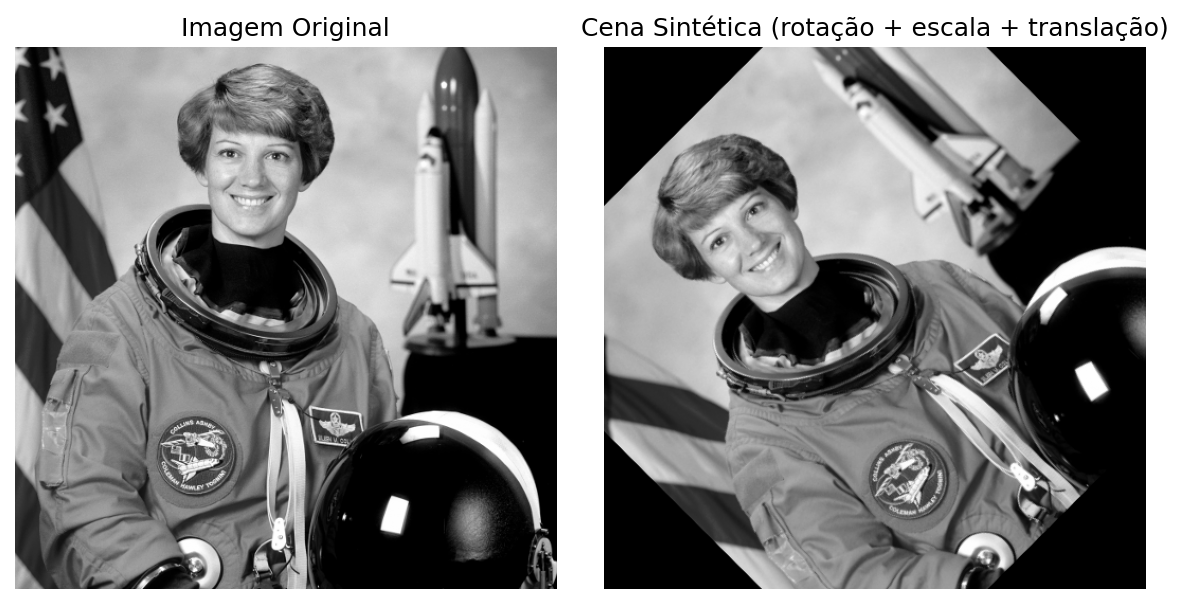

**Figura 8.3:** Imagem original e cena sintética gerada por rotação, escala e translação — simulando a mesma cena vista de outro ângulo.


In [80]:
img_original = cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2GRAY)

img_cena = mm.rotate(img_original, angle=45)

mm.show([img_original, img_cena], titles=["Imagem Original", "Cena Sintética (rotação + escala + translação)"], cols=2, figsize=(8, 4))


Em seguida, o detector/descritor ORB é aplicado a ambas as imagens, e os
descritores são comparados por força bruta (`BFMatcher`) com distância de
Hamming, mantendo apenas correspondências mútuas (`crossCheck=True`).

Pontos de interesse detectados: 500 (original), 500 (cena)
Correspondências encontradas: 332


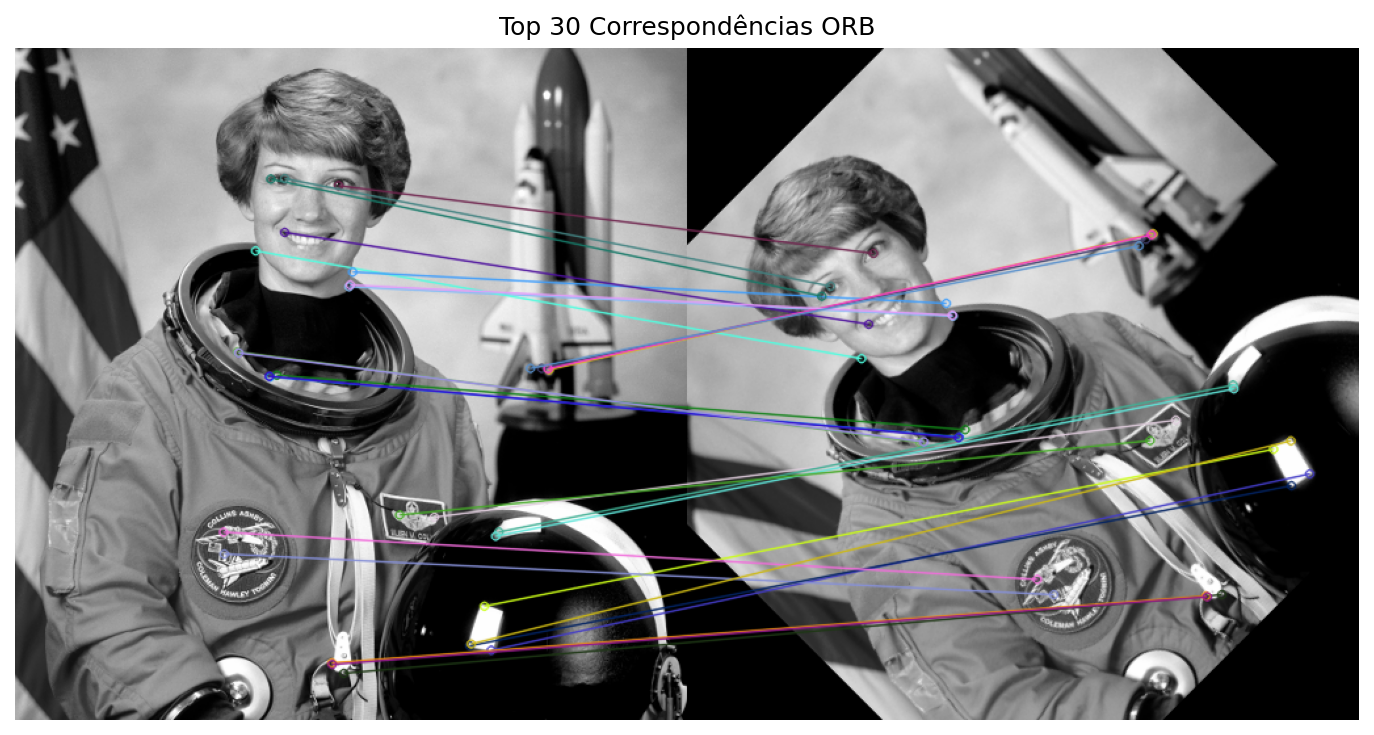

**Figura 8.4:** As 30 melhores correspondências de características ORB entre a imagem original e a cena sintética, antes da filtragem por RANSAC.


In [81]:
orb = cv2.ORB_create(nfeatures=500)
kp1, des1 = orb.detectAndCompute(img_original, None)
kp2, des2 = orb.detectAndCompute(img_cena, None)
print(f"Pontos de interesse detectados: {len(kp1)} (original), {len(kp2)} (cena)")

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda m: m.distance)
print(f"Correspondências encontradas: {len(matches)}")

img_matches = cv2.drawMatches(
    img_original, kp1, img_cena, kp2, matches[:30], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
mm.show([img_matches], titles=["Top 30 Correspondências ORB"], cols=1, figsize=(10, 5))


### 8.4.1 Estimando a Homografia com RANSAC

Mesmo com a distância de Hamming, algumas correspondências estarão incorretas (falsos positivos de *matching*). A **homografia** — a mesma transformação de perspectiva utilizada no Capítulo 6 para retificar documentos — pode ser estimada de forma robusta a essas correspondências espúrias por meio do algoritmo **RANSAC** (*Random Sample Consensus*), detalhado na próxima seção.

Matriz de homografia estimada:
[[ 7.06308066e-01  7.00156488e-01 -1.04292350e+02]
 [-7.07502031e-01  7.04689716e-01  2.55851719e+02]
 [ 2.46728727e-06 -1.01575399e-05  1.00000000e+00]]

Inliers: 321 de 332 correspondências (96.7%)


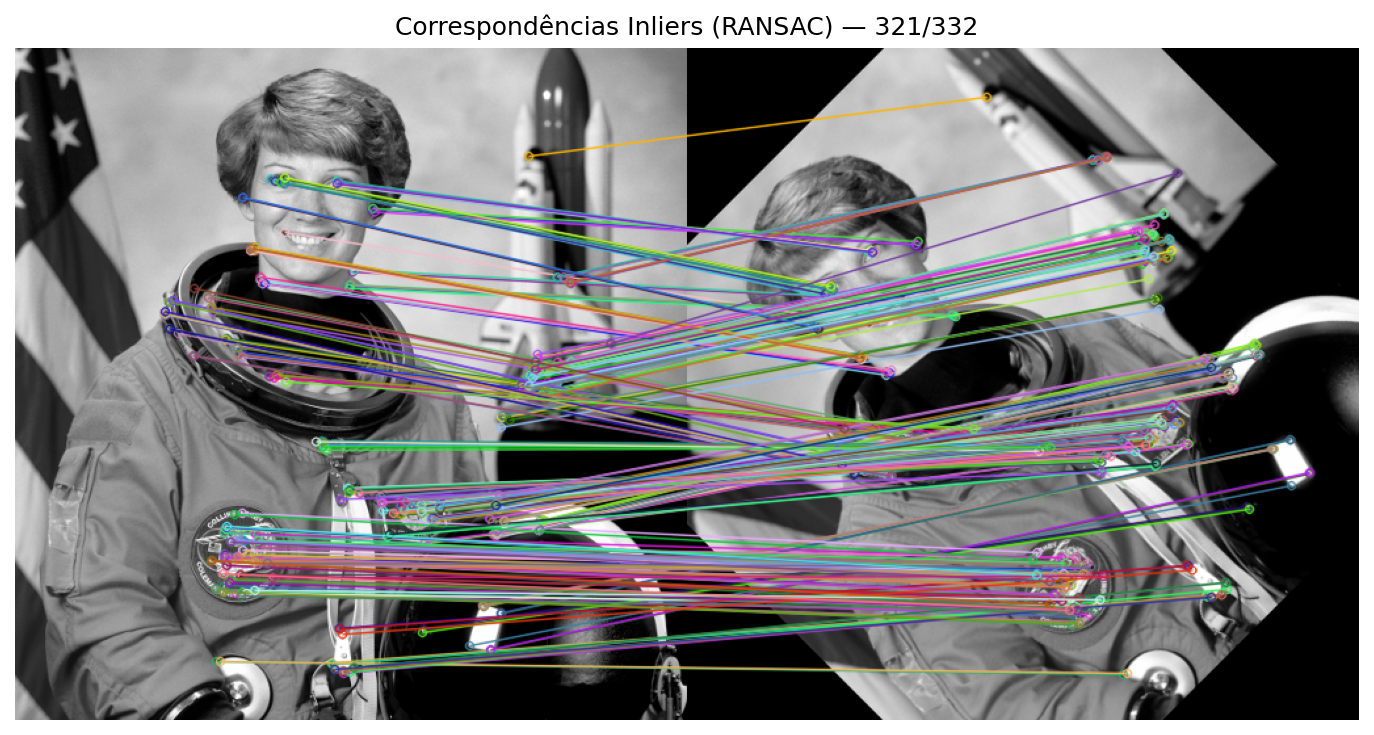

**Figura 8.5:** Correspondências classificadas como inliers (verde) pelo RANSAC ao estimar a homografia entre as duas imagens.


In [82]:
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

H, mascara_inliers = cv2.findHomography(pts1, pts2, cv2.RANSAC, ransacReprojThreshold=5.0)
n_inliers = int(mascara_inliers.sum())
print(f"Matriz de homografia estimada:\n{H}\n")
print(f"Inliers: {n_inliers} de {len(matches)} correspondências ({100*n_inliers/len(matches):.1f}%)")

img_inliers = cv2.drawMatches(
    img_original, kp1, img_cena, kp2, matches, None,
    matchesMask=mascara_inliers.ravel().tolist(),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
mm.show([img_inliers], titles=[f"Correspondências Inliers (RANSAC) — {n_inliers}/{len(matches)}"], cols=1, figsize=(10, 5))


## 8.5 Modelagem Matemática: Homografia e RANSAC

### 8.5.1 Homografia

Uma homografia $H$ é uma matriz $3\times3$ que mapeia pontos de um plano
projetivo a outro:

$$
\begin{bmatrix} x' \\ y' \\ w' \end{bmatrix} =
\begin{bmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ h_{31} & h_{32} & h_{33} \end{bmatrix}
\begin{bmatrix} x \\ y \\ 1 \end{bmatrix},
\qquad
\left(\frac{x'}{w'}, \frac{y'}{w'}\right) \text{ é o ponto correspondente.}
$$

Como $H$ possui 8 graus de liberdade (a matriz é definida a menos de escala),
são necessários, no mínimo, **4 pares de pontos correspondentes** para
estimá-la — porém, na prática, o conjunto de correspondências obtido pelo
ORB contém múltiplos pares incorretos.

### 8.5.2 RANSAC

O **RANSAC** estima um modelo robusto a essas correspondências espúrias
(*outliers*) por meio de um processo iterativo:

1. Sorteia-se aleatoriamente um subconjunto mínimo de correspondências
   (4 pares, no caso da homografia);
2. Estima-se o modelo (a homografia) a partir desse subconjunto;
3. Conta-se quantas correspondências do conjunto total são consistentes com
   esse modelo — os **inliers** — dentro de uma margem de erro
   (`ransacReprojThreshold`);
4. Repete-se o processo por um número de iterações, mantendo o modelo com o
   **maior número de inliers**;
5. Ao final, o modelo é **refinado** utilizando apenas os inliers do melhor
   conjunto encontrado.

Esse procedimento é bastante geral e não se restringe à homografia — o
mesmo princípio pode ajustar retas, círculos ou qualquer modelo
paramétrico na presença de dados ruidosos, como demonstrado no simulador a
seguir.

O simulador a seguir ilustra o funcionamento do RANSAC em um cenário
simplificado — o ajuste de uma **reta** a um conjunto de pontos com
aproximadamente 25% de *outliers*. Ajuste o limiar de distância e clique em
"Rodar RANSAC" para observar como o algoritmo separa inliers de outliers e
ajusta o modelo apenas com base nos primeiros.

In [68]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML(r"""
<div id="cap08_Root">
<style>
  #cap08_Root * { box-sizing: border-box; }
  #cap08_Root { font-family: sans-serif; padding: 10px; max-width: 760px; margin: 0 auto; color: #374151; }
  #cap08_Root canvas { display: block; border-radius: 6px; border: 1px solid #d1d5db; background: #fff; }
  #cap08_Root button { font-size: 11px; padding: 6px 12px; border-radius: 4px; border: 1px solid #d1d5db; background: #fff; color: #374151; cursor: pointer; transition: background 0.15s; }
  #cap08_Root button:hover { background: #f3f4f6; }
  #cap08_Root button.cap08_primary { background: #4f46e5; color: #fff; border-color: #4f46e5; }
  #cap08_Root input[type=range] { width: 100%; accent-color: #6366f1; }
  .cap08_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .cap08_row { display: flex; align-items: center; gap: 10px; flex-wrap: wrap; }
  .cap08_stat { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px 14px; text-align: center; min-width: 90px; }
  .cap08_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 2px; }
  .cap08_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; color: #4f46e5; }
  .cap08_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #a5b4fc; background: #eef2ff; color: #4338ca; }
  .cap08_legend { display: flex; align-items: center; gap: 6px; font-size: 11px; }
  .cap08_dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; border: 1px solid rgba(0,0,0,0.2); }
</style>

<div class="cap08_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">🎯 Simulador: RANSAC — Ajuste de Reta Robusto a Outliers</span>
  <span class="cap08_pill">Dados com ~25% de correspondências espúrias</span>
</div>

<div class="cap08_panel">
  <div class="cap08_row" style="margin-bottom:8px;">
    <div class="cap08_stat"><div class="cap08_stat_label">Limiar (px)</div><div id="cap08_thVal" class="cap08_stat_value">15</div></div>
    <div class="cap08_stat"><div class="cap08_stat_label">Inliers</div><div id="cap08_nIn" class="cap08_stat_value">–</div></div>
    <div class="cap08_stat"><div class="cap08_stat_label">Outliers</div><div id="cap08_nOut" class="cap08_stat_value">–</div></div>
    <div class="cap08_stat"><div class="cap08_stat_label">Iterações</div><div id="cap08_nIter" class="cap08_stat_value">–</div></div>
    <button id="cap08_btnRun" class="cap08_primary">▶ Rodar RANSAC</button>
    <button id="cap08_btnNovo">🎲 Novos Pontos</button>
  </div>
  <label style="font-size:11px;font-weight:600;color:#374151;">Limiar de distância (define quem é inlier): <span id="cap08_slVal">15</span> px</label>
  <input type="range" id="cap08_slider" min="4" max="40" step="1" value="15">
</div>

<canvas id="cap08_canvas" width="640" height="320"></canvas>

<div class="cap08_panel" style="margin-top:10px;">
  <div class="cap08_row" style="justify-content:space-between;">
    <div class="cap08_legend"><span class="cap08_dot" style="background:#9ca3af;"></span> Pontos (ainda não classificados)</div>
    <div class="cap08_legend"><span class="cap08_dot" style="background:#16a34a;"></span> Inliers</div>
    <div class="cap08_legend"><span class="cap08_dot" style="background:#dc2626;"></span> Outliers</div>
  </div>
</div>
</div>

<script>
(function(){
  const cap08_canvas = document.getElementById("cap08_canvas");
  const cap08_ctx = cap08_canvas.getContext("2d");
  const cap08_W = cap08_canvas.width, cap08_H = cap08_canvas.height;

  let cap08_pontos = [];
  let cap08_limiar = 15;
  let cap08_modelo = null; // {x1,y1,x2,y2, inliersIdx}

  function cap08_gerarPontos(){
    const pontos = [];
    const a = 0.5, b = 60; // reta y = a*x + b (referência)
    for (let i = 0; i < 30; i++){
      const x = 40 + Math.random() * (cap08_W - 80);
      const yIdeal = a * x + b;
      const y = yIdeal + (Math.random() - 0.5) * 20;
      pontos.push({x: x, y: Math.min(Math.max(y, 20), cap08_H - 20)});
    }
    for (let i = 0; i < 10; i++){
      pontos.push({
        x: 40 + Math.random() * (cap08_W - 80),
        y: 20 + Math.random() * (cap08_H - 40)
      });
    }
    return pontos;
  }

  function cap08_distPontoReta(px, py, x1, y1, x2, y2){
    const num = Math.abs((y2 - y1) * px - (x2 - x1) * py + x2 * y1 - y2 * x1);
    const den = Math.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2);
    return den === 0 ? Infinity : num / den;
  }

  function cap08_ajustarMinimosQuadrados(indices){
    let somaX = 0, somaY = 0, somaXY = 0, somaXX = 0;
    const n = indices.length;
    indices.forEach(i => {
      const p = cap08_pontos[i];
      somaX += p.x; somaY += p.y; somaXY += p.x * p.y; somaXX += p.x * p.x;
    });
    const denom = (n * somaXX - somaX * somaX);
    if (Math.abs(denom) < 1e-6) return null;
    const a = (n * somaXY - somaX * somaY) / denom;
    const b = (somaY - a * somaX) / n;
    return {a: a, b: b};
  }

  function cap08_rodarRansac(){
    const numIter = 60;
    let melhorInliers = [];
    let melhorP1 = null, melhorP2 = null;

    for (let it = 0; it < numIter; it++){
      const i1 = Math.floor(Math.random() * cap08_pontos.length);
      let i2 = Math.floor(Math.random() * cap08_pontos.length);
      while (i2 === i1) i2 = Math.floor(Math.random() * cap08_pontos.length);
      const p1 = cap08_pontos[i1], p2 = cap08_pontos[i2];

      const inliersAtual = [];
      cap08_pontos.forEach((p, idx) => {
        const d = cap08_distPontoReta(p.x, p.y, p1.x, p1.y, p2.x, p2.y);
        if (d <= cap08_limiar) inliersAtual.push(idx);
      });

      if (inliersAtual.length > melhorInliers.length){
        melhorInliers = inliersAtual;
        melhorP1 = p1; melhorP2 = p2;
      }
    }

    const ajuste = cap08_ajustarMinimosQuadrados(melhorInliers) ||
      {a: (melhorP2.y - melhorP1.y) / (melhorP2.x - melhorP1.x + 1e-6), b: melhorP1.y};

    cap08_modelo = {
      a: ajuste.a, b: ajuste.b,
      inliersIdx: new Set(melhorInliers),
      numIter: numIter
    };
    cap08_render();
  }

  function cap08_render(){
    cap08_ctx.clearRect(0, 0, cap08_W, cap08_H);

    cap08_pontos.forEach((p, idx) => {
      let cor = "#9ca3af";
      if (cap08_modelo){
        cor = cap08_modelo.inliersIdx.has(idx) ? "#16a34a" : "#dc2626";
      }
      cap08_ctx.beginPath();
      cap08_ctx.arc(p.x, p.y, 6, 0, 2 * Math.PI);
      cap08_ctx.fillStyle = cor;
      cap08_ctx.fill();
      cap08_ctx.lineWidth = 1.2;
      cap08_ctx.strokeStyle = "#ffffff";
      cap08_ctx.stroke();
    });

    if (cap08_modelo){
      const x0 = 0, x1 = cap08_W;
      const y0 = cap08_modelo.a * x0 + cap08_modelo.b;
      const y1 = cap08_modelo.a * x1 + cap08_modelo.b;
      cap08_ctx.beginPath();
      cap08_ctx.moveTo(x0, y0);
      cap08_ctx.lineTo(x1, y1);
      cap08_ctx.strokeStyle = "#2563eb";
      cap08_ctx.lineWidth = 2.5;
      cap08_ctx.stroke();

      document.getElementById("cap08_nIn").textContent = cap08_modelo.inliersIdx.size;
      document.getElementById("cap08_nOut").textContent = cap08_pontos.length - cap08_modelo.inliersIdx.size;
      document.getElementById("cap08_nIter").textContent = cap08_modelo.numIter;
    } else {
      document.getElementById("cap08_nIn").textContent = "–";
      document.getElementById("cap08_nOut").textContent = "–";
      document.getElementById("cap08_nIter").textContent = "–";
    }
    document.getElementById("cap08_thVal").textContent = cap08_limiar;
  }

  document.getElementById("cap08_slider").addEventListener("input", function(ev){
    cap08_limiar = parseInt(ev.target.value, 10);
    document.getElementById("cap08_slVal").textContent = cap08_limiar;
    if (cap08_modelo) cap08_rodarRansac();
    else cap08_render();
  });

  document.getElementById("cap08_btnRun").addEventListener("click", cap08_rodarRansac);

  document.getElementById("cap08_btnNovo").addEventListener("click", function(){
    cap08_pontos = cap08_gerarPontos();
    cap08_modelo = null;
    cap08_render();
  });

  cap08_pontos = cap08_gerarPontos();
  cap08_render();
})();
</script>
""")


**Figura 8.6:** Simulador interativo do algoritmo RANSAC: ajuste o limiar de distância e execute o algoritmo para observar a separação entre inliers e outliers.


> ### 📝 8.6 🧠 Por que funciona? — Robustez por consenso
>
> O RANSAC não tenta usar todos os dados de uma vez — ao contrário da
> regressão por mínimos quadrados tradicional, que é fortemente distorcida
> por *outliers*, o RANSAC ajusta modelos a partir de pequenas amostras
> aleatórias e **confia no consenso**: o modelo correto tende a ser
> consistente com uma grande fração dos dados (os inliers), enquanto um
> modelo ajustado a uma amostra "azarada" (contendo *outliers*) raramente
> será consistente com muitos outros pontos.
>
> **Parâmetros críticos:** o limiar de distância define o quão "rigorosa"
> é a definição de inlier — um limiar muito pequeno pode descartar inliers
> legítimos (dados com ruído natural); um limiar muito grande pode aceitar
> outliers como se fossem inliers, contaminando o modelo final. O número de
> iterações deve ser grande o suficiente para que, estatisticamente, pelo
> menos uma amostra aleatória livre de outliers seja sorteada.
>
> **Limitações:** o RANSAC assume que existe **um único modelo dominante**
> nos dados; funciona mal se os inliers representam menos da metade do
> conjunto, ou se há múltiplas estruturas igualmente relevantes (por
> exemplo, dois planos distintos em uma cena 3D).

## 8.7 Detecção de Objetos: Haar Cascade (Viola-Jones)

A correspondência de características responde "onde está o mesmo padrão
que já conheço?". A **detecção de objetos** propõe um problema diferente:
"onde está um padrão de uma **categoria genérica** (por exemplo, "rosto
humano"), mesmo que eu nunca tenha visto esta pessoa específica antes?".

O algoritmo de **Haar Cascade**, proposto por Viola e Jones em 2001, foi o
primeiro método capaz de realizar detecção de faces em tempo real, e
permanece disponível no OpenCV para fins didáticos e aplicações leves.
Seu funcionamento combina três ideias:

1. **Características do tipo Haar:** filtros retangulares simples (por
   exemplo, a diferença de intensidade entre uma região clara e uma
   região escura adjacente) que capturam padrões grosseiros, mas
   informativos, como "a região dos olhos costuma ser mais escura que a
   da testa";
2. **Imagem integral:** uma estrutura de dados que permite calcular a soma
   de intensidades de qualquer região retangular em tempo constante,
   tornando viável avaliar milhares de características Haar em diferentes
   posições e escalas rapidamente:
   $$
   I_{\text{integral}}(x, y) = \sum_{x' \leq x,\, y' \leq y} I(x', y');
   $$
3. **Cascata de classificadores fracos (AdaBoost):** em vez de um único
   classificador complexo, uma sequência de classificadores simples é
   aplicada em cascata — janelas que claramente não contêm o objeto são
   descartadas nos primeiros estágios (baratos), e apenas as candidatas
   promissoras avançam para estágios mais rigorosos, tornando a busca por
   toda a imagem, em múltiplas escalas (*sliding window* multi-escala),
   computacionalmente viável.

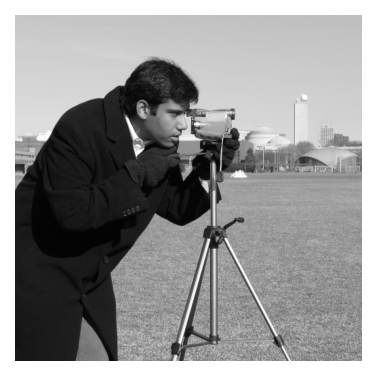

In [102]:
mm.show(skdata.camera())

Regiões detectadas como face: 1


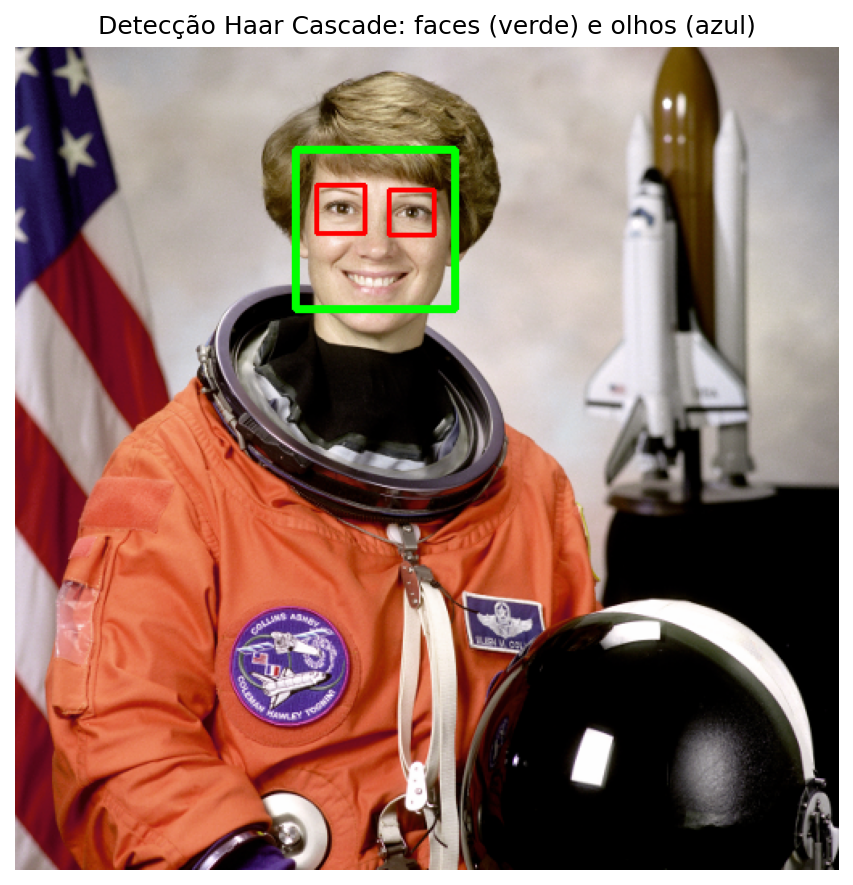

**Figura 8.7:** Detecção de faces e olhos com Haar Cascade na imagem astronaut (scikit-image).


In [108]:
def get_cascade(nome):
    """Baixa (se necessário) e carrega um classificador Haar Cascade do OpenCV."""
    caminho = f"haarcascades/{nome}"
    os.makedirs("haarcascades", exist_ok=True)
    if not os.path.exists(caminho):
        url = f"https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/{nome}"
        urllib.request.urlretrieve(url, caminho)
    return cv2.CascadeClassifier(caminho)

face_cascade = get_cascade("haarcascade_frontalface_default.xml")
eye_cascade = get_cascade("haarcascade_eye.xml")

# Escala de cinza + equalização de histograma (Capítulo 3), como o Haar Cascade espera
img_rgb = mm.rotate(skdata.astronaut(), angle=0)
img_gray = cv2.equalizeHist(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY))

# Detecta faces e, dentro de cada uma, tenta detectar os olhos, alterar minNeighbors
faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.03, minNeighbors=10, minSize=(70, 70))

img_anotada = img_rgb.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(img_anotada, (x, y), (x + w, y + h), (0, 255, 0), 3)
    olhos = eye_cascade.detectMultiScale(img_gray[y:y+h, x:x+w], scaleFactor=1.03, minNeighbors=5, minSize=(15, 15))
    for (ex, ey, ew, eh) in olhos:
        cv2.rectangle(img_anotada, (x+ex, y+ey), (x+ex+ew, y+ey+eh), (255, 0, 0), 2)

print(f"Regiões detectadas como face: {len(faces)}")
mm.show([img_anotada], titles=["Detecção Haar Cascade: faces (verde) e olhos (azul)"], cols=1, figsize=(6, 6))

> ### 📝 8.8 🧠 Por que funciona? — E por que também falha
>
> Ao executar a célula acima, o classificador de fato localiza corretamente
> o rosto na imagem — e, dentro dele, os dois olhos. Mas repare: **uma
> segunda região também foi marcada como "face"**, sobre um trecho do
> traje espacial. Trata-se de um **falso positivo** genuíno: o padrão de
> contraste local daquela região do tecido, por coincidência, é suficiente
> para satisfazer os filtros Haar em todos os estágios da cascata.
>
> Esse resultado, embora indesejado, ilustra exatamente a principal
> **limitação** do Haar Cascade: por depender de características
> extremamente genéricas (diferenças de intensidade entre blocos
> retangulares), o algoritmo é sensível a texturas e padrões que
> "parecem" o suficiente com um rosto do ponto de vista desses filtros,
> mesmo sem qualquer semântica real. Além disso, o Haar Cascade tende a
> funcionar bem apenas para **faces frontais**, sendo degradado por
> variações de pose, oclusão parcial ou iluminação muito diferente daquela
> presente nas imagens de treinamento originais.
>
> **Quando utilizar:** Haar Cascade continua sendo uma escolha razoável
> quando há restrição severa de poder computacional (ex.: dispositivos
> embarcados) e a aplicação tolera uma taxa moderada de falsos positivos.
> Para aplicações mais exigentes, os detectores modernos baseados em redes
> neurais profundas — apresentados adiante — reduzem drasticamente esse
> tipo de erro.

## 8.9 Detecção de Objetos: Caixas Delimitadoras, IoU e NMS

Praticamente todo detector de objetos — do Haar Cascade aos modelos
modernos baseados em redes neurais profundas — expressa suas detecções
como **caixas delimitadoras** (*bounding boxes*), tipicamente
representadas por quatro números: $(x_{min}, y_{min}, x_{max}, y_{max})$.

### 8.9.1 Intersection over Union (IoU)

Para avaliar o quão bem uma caixa detectada coincide com a localização
real de um objeto — ou o quanto duas detecções se sobrepõem — utiliza-se
a métrica **IoU**:

$$
\mathrm{IoU}(A, B) = \frac{\text{área}(A \cap B)}{\text{área}(A \cup B)},
\qquad \mathrm{IoU} \in [0, 1].
$$

Um IoU de 1 indica sobreposição perfeita; um IoU de 0 indica caixas
completamente disjuntas. Na prática, é comum considerar uma detecção
"correta" quando seu IoU com a localização real (*ground truth*) excede
um limiar, tipicamente 0,5.

A biblioteca didática `morph` disponibiliza essa métrica pronta para uso através do método `mm.IoU`, adotado nas demonstrações a seguir e retomado adiante na avaliação de anotações geradas automaticamente.

### 8.9.2 Supressão de Não-Máximos (NMS)

Detectores do tipo *sliding window* (como o Haar Cascade) tipicamente
produzem **múltiplas detecções sobrepostas** para o mesmo objeto — em
posições e escalas ligeiramente diferentes, todas com alta confiança. A
**supressão de não-máximos** elimina essa redundância:

1. Ordena-se as detecções por confiança (pontuação), da maior para a
   menor;
2. Seleciona-se a detecção de maior confiança e descarta-se todas as
   demais cujo IoU com ela exceda um limiar;
3. Repete-se o processo com as detecções restantes, até que nenhuma
   sobre.

Caixas antes do NMS: 5 | Caixas após o NMS: 2
IoU entre a 1ª e a 2ª caixa: 0.775


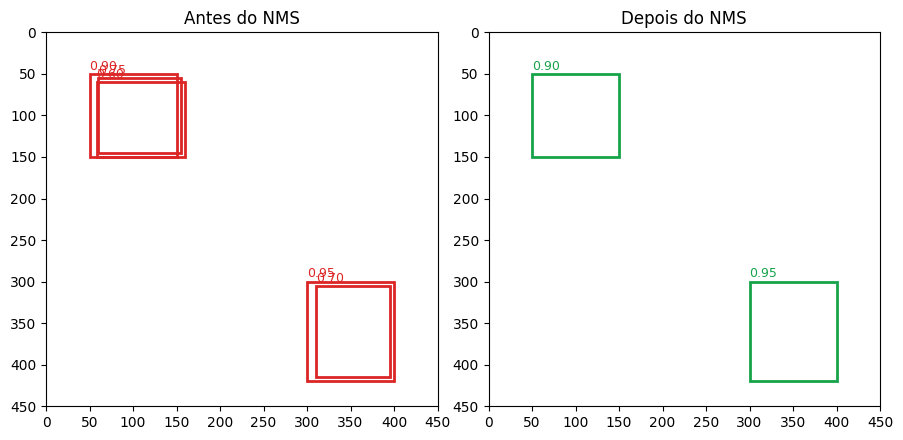

**Figura 8.8:** Efeito da Supressão de Não-Máximos (NMS): múltiplas detecções redundantes (esquerda) são reduzidas a uma detecção por objeto (direita).


In [70]:
def calcular_iou(caixa_a, caixa_b):
    # As caixas aqui estão no formato (xmin, ymin, xmax, ymax); mm.IoU espera
    # (x, y, largura, altura), de modo que a conversão é feita antes da chamada.
    ax, ay, aw, ah = caixa_a[0], caixa_a[1], caixa_a[2] - caixa_a[0], caixa_a[3] - caixa_a[1]
    bx, by, bw, bh = caixa_b[0], caixa_b[1], caixa_b[2] - caixa_b[0], caixa_b[3] - caixa_b[1]
    return mm.IoU((ax, ay, aw, ah), (bx, by, bw, bh))

def supressao_nao_maximos(caixas, pontuacoes, limiar_iou=0.4):
    ordem = np.argsort(pontuacoes)[::-1]
    mantidas = []
    ordem = list(ordem)
    while len(ordem) > 0:
        atual = ordem.pop(0)
        mantidas.append(atual)
        ordem = [i for i in ordem if calcular_iou(caixas[atual], caixas[i]) < limiar_iou]
    return mantidas

caixas = np.array([
    [50, 50, 150, 150], [60, 55, 155, 145], [58, 60, 160, 150],
    [300, 300, 400, 420], [310, 305, 395, 415],
])
pontuacoes = np.array([0.90, 0.75, 0.60, 0.95, 0.70])

mantidas = supressao_nao_maximos(caixas, pontuacoes, limiar_iou=0.4)
print(f"Caixas antes do NMS: {len(caixas)} | Caixas após o NMS: {len(mantidas)}")
print(f"IoU entre a 1ª e a 2ª caixa: {calcular_iou(caixas[0], caixas[1]):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
for i, c in enumerate(caixas):
    ax[0].add_patch(patches.Rectangle((c[0], c[1]), c[2]-c[0], c[3]-c[1], fill=False, edgecolor="#dc2626", linewidth=2))
    ax[0].text(c[0], c[1]-5, f"{pontuacoes[i]:.2f}", color="#dc2626", fontsize=9)
ax[0].set_xlim(0, 450); ax[0].set_ylim(450, 0); ax[0].set_title("Antes do NMS")

for i in mantidas:
    c = caixas[i]
    ax[1].add_patch(patches.Rectangle((c[0], c[1]), c[2]-c[0], c[3]-c[1], fill=False, edgecolor="#16a34a", linewidth=2))
    ax[1].text(c[0], c[1]-5, f"{pontuacoes[i]:.2f}", color="#16a34a", fontsize=9)
ax[1].set_xlim(0, 450); ax[1].set_ylim(450, 0); ax[1].set_title("Depois do NMS")
plt.tight_layout()


> ### 📝 8.10 🧠 Por que funciona? — NMS como "faxina" pós-detecção
>
> O NMS não melhora a qualidade individual de cada detecção — ele apenas
> remove redundância. Sua eficácia depende diretamente do limiar de IoU
> escolhido: um limiar muito baixo pode eliminar detecções de objetos
> genuinamente próximos entre si (dois rostos lado a lado, por exemplo);
> um limiar muito alto pode deixar passar múltiplas caixas para o mesmo
> objeto. Esse é exatamente o tipo de ajuste fino que, no Haar Cascade,
> ajudaria a reduzir — mas não eliminaria — o falso positivo observado na
> seção anterior, caso ele fosse detectado repetidamente em escalas
> próximas.

## 8.11 Segmentação Visual: Semântica, de Instâncias e Panóptica

Uma caixa delimitadora localiza um objeto de forma aproximada — mas não
diz exatamente quais pixels pertencem a ele. A **segmentação visual**
resolve essa limitação, atribuindo um rótulo a **cada pixel** da imagem.
Três paradigmas são amplamente utilizados, e a distinção entre eles é uma
fonte comum de confusão:

| Paradigma | Pergunta que responde | Distingue objetos individuais da mesma classe? |
|---|---|---|
| **Semântica** | "A que classe pertence cada pixel?" | Não — todos os pixels de "pessoa" recebem o mesmo rótulo, mesmo que sejam pessoas diferentes |
| **De instâncias** | "Quais pixels pertencem a cada objeto individual?" | Sim — mas tipicamente apenas para classes "contáveis" (objetos), ignorando o fundo |
| **Panóptica** | Combinação das duas anteriores | Sim — cada pixel recebe uma classe semântica **e**, quando aplicável, um identificador de instância |

A segmentação semântica trata a imagem inteira, incluindo regiões de
fundo não contáveis (céu, grama, estrada); a segmentação de instâncias
foca em objetos discretos e contáveis, distinguindo cada ocorrência; a
segmentação panóptica, formalizada em 2019, unifica os dois paradigmas em
uma única representação.

Antes do amplo uso de redes neurais profundas — que serão apresentadas no
Capítulo 9 — versões simplificadas de segmentação semântica e de
instâncias já eram possíveis com técnicas clássicas, como demonstrado a
seguir.

Instâncias (moedas individuais) identificadas: 26


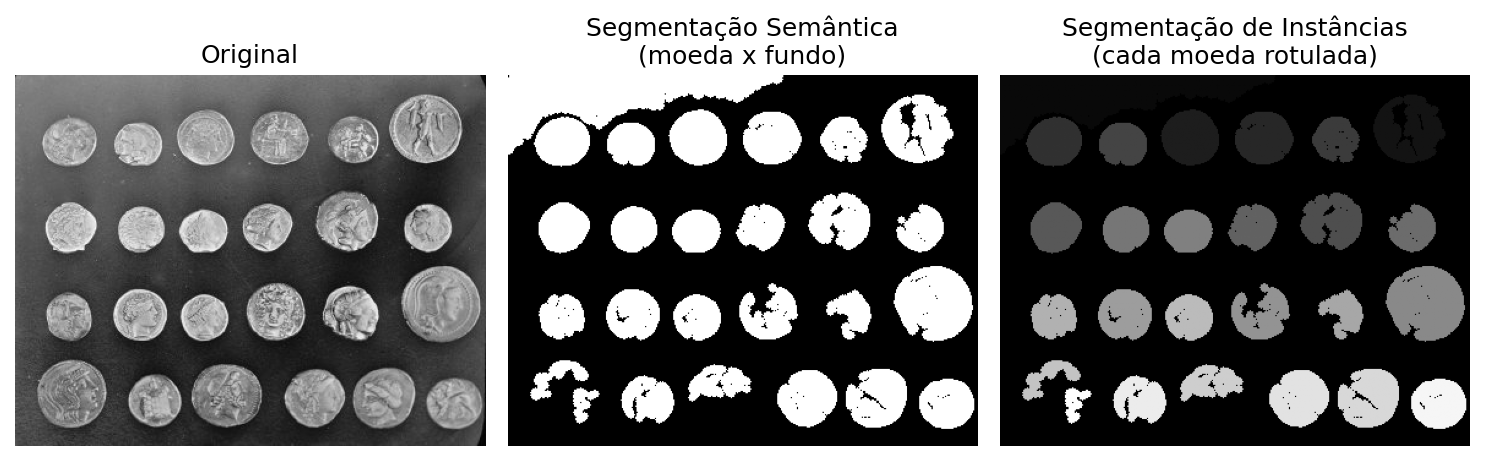

**Figura 8.9:** Segmentação clássica (não baseada em aprendizado profundo): máscara semântica (moeda x fundo) via limiarização de Otsu, e segmentação de instâncias via rotulagem de componentes conectados.


In [71]:
img_moedas = skdata.coins()

limiar = mm.neg(mm.threshold(img_moedas))
mascara_bin = img_moedas > limiar

# Limpeza morfológica: remove ruído e pequenos artefatos da limiarização
mascara_limpa = opening(mascara_bin, disk(3))
mascara_limpa = remove_small_objects(mascara_limpa, max_size=200)

# Segmentação semântica: apenas "moeda" x "fundo"
mascara_semantica = (mascara_limpa.astype(np.uint8)) * 255

# Segmentação de instâncias: cada componente conectado recebe um rótulo distinto
rotulos_instancias = label(mascara_limpa)
print(f"Instâncias (moedas individuais) identificadas: {rotulos_instancias.max()}")

mm.show(
    [img_moedas, mascara_semantica, rotulos_instancias],
    titles=["Original", "Segmentação Semântica\n(moeda x fundo)", "Segmentação de Instâncias\n(cada moeda rotulada)"],
    cols=3, figsize=(10, 3.5)
)


> ### 📝 8.12 🧠 Por que funciona? — E onde a abordagem clássica esbarra
>
> A limiarização de Otsu (Capítulo 4) mais limpeza morfológica funciona bem
> aqui porque as moedas têm contraste consistente com o fundo e não se
> tocam de forma significativa — condições favoráveis. A rotulagem de
> componentes conectados então separa "instâncias" apenas por estarem
> espacialmente desconectadas na máscara binária.
>
> Essa abordagem, no entanto, **não escala**: ela falha imediatamente diante
> de objetos da mesma classe que se sobrepõem parcialmente (a rotulagem de
> componentes os fundiria em uma única instância), de classes com aparência
> muito variável (não há um único limiar de intensidade capaz de separar
> "gato" de "não-gato" em fotos naturais), ou de cenas com múltiplas
> classes semanticamente distintas simultaneamente. É exatamente essa
> lacuna que os modelos de segmentação baseados em redes neurais profundas
> — capazes de aprender a noção de "objeto" e "classe" diretamente dos
> dados, em vez de depender de contraste de intensidade — vêm preencher,
> como será estudado no Capítulo 9.
>
> A **segmentação panóptica** completa o quadro: ela aplicaria a
> segmentação semântica ao fundo (regiões não contáveis, se houvesse
> alguma nesta imagem) e a segmentação de instâncias às moedas,
> combinando ambos os resultados em um único mapa consistente.

### 8.12.1 Medição e Extração de Atributos com `mm.measure`

A biblioteca pedagógica `morph` disponibiliza a função `mm.measure` para analisar componentes conexos e retornar uma lista estruturada de dicionários contendo os descritores geométricos de cada objeto:

$$\text{Circularidade} = \frac{4 \pi \cdot \text{Área}}{\text{Perímetro}^2}$$

$$\text{Solidez} = \frac{\text{Área}}{\text{Área do Fecho Convexo}}$$

In [72]:
# Simulação de imagem de objetos industriais (moedas)
img_moedas = skdata.coins()
limiar = mm.threshold(img_moedas)
mascara_binaria = (img_moedas > limiar).astype(np.uint8) * 255

# Processamento morfológico para isolar componentes conexos
mascara_limpa = cv2.morphologyEx(mascara_binaria, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)))

# Computar os descritores morfológicos para cada componente detectado
medidas = mm.measure(mm.neg(mascara_limpa), precision=0.01)

# Apresentação tabular das medidas dos primeiros componentes extraídos
if medidas:
    print(f"Total de objetos catalogados: {len(medidas)}")
    print(f"{'ID':<4}{'Área':<8}{'Perímetro':<12}{'Circularidade':<15}{'Solidez':<10}{'Vértices':<8}")
    for m in medidas[:5]:
        print(f"{m['id']:<4}{m['area']:<8.1f}{m['perimeter']:<12.2f}{m['circularity']:<15.3f}{m['solidity']:<10.3f}{m['vertices']:<8}")

Total de objetos catalogados: 50
ID  Área    Perímetro   Circularidade  Solidez   Vértices
1   1413.0  141.05      0.892          0.984     13      
2   0.0     2.00        0.000          0.000     2       
3   1333.0  139.54      0.860          0.974     11      
4   1675.5  155.78      0.868          0.980     12      
5   1892.5  163.30      0.892          0.986     11      


### 8.12.2 Exportação de Anotações: de `mm.measure` ao Formato YOLO

Os descritores geométricos calculados por `mm.measure` já contêm, para
cada componente, a caixa delimitadora `bbox = (x, y, w, h)` em coordenadas
de pixel. Essa informação é suficiente para gerar automaticamente um
conjunto de anotações a partir de uma simples segmentação, sem qualquer
rotulagem manual — a mesma estratégia empregada na prática para *bootstrap*
de conjuntos de treinamento de detectores.

A função `mm.saveMeasures` converte a lista de medidas em um arquivo de
anotações em um dos três formatos:

- `fmt="csv"`: uma linha por objeto, com todos os descritores (área,
  perímetro, centro, *bbox*, circularidade, solidez, vértices), útil para
  análise exploratória e para os exercícios de classificação por atributos
  geométricos (Capítulo 7);
- `fmt="txt"`: formato tabular simples, sem cabeçalho;
- `fmt="yolo"`: uma linha por objeto no padrão `classe x_c y_c w h`, com
  todas as quatro últimas coordenadas normalizadas pelas dimensões da
  imagem, $x_c, y_c \in [0,1]$:

$$
x_c = \frac{x + w/2}{W_{\text{img}}}, \quad
y_c = \frac{y + h/2}{H_{\text{img}}}, \quad
w_n = \frac{w}{W_{\text{img}}}, \quad
h_n = \frac{h}{H_{\text{img}}}
$$

em que $W_{\text{img}}$ e $H_{\text{img}}$ são a largura e a altura da
imagem original. Esse é o formato de anotação adotado pela família de
detectores YOLO (*You Only Look Once*), apresentada de forma conceitual
adiante e estudada em maior profundidade no **Capítulo 9**.

In [73]:
# Exporta as medidas extraídas das moedas em dois formatos de anotação
altura_img, largura_img = img_moedas.shape[:2]

mm.saveMeasures("moedas.csv", medidas, fmt="csv")
mm.saveMeasures("moedas.txt", medidas, fmt="yolo",
                 img_width=largura_img, img_height=altura_img, class_id=0)

print("--- Trecho de moedas.csv ---")
with open("moedas.csv") as f:
    for linha in f.readlines()[:4]:
        print(linha.rstrip())

print("\n--- Trecho de moedas.txt (formato YOLO) ---")
with open("moedas.txt") as f:
    for linha in f.readlines()[:4]:
        print(linha.rstrip())

--- Trecho de moedas.csv ---
id,area,perimeter,cx,cy,x,y,w,h,circularity,solidity,vertices
1,1413.0,141.05,358.1,267.93,336,248,45,41,0.892,0.984,13
2,0.0,2.0,0,0,11,246,1,2,0.0,0,2
3,1333.0,139.54,113.79,265.81,92,245,44,42,0.86,0.974,11

--- Trecho de moedas.txt (formato YOLO) ---
0 0.933594 0.886139 0.117188 0.135314
0 0.029948 0.815182 0.002604 0.006601
0 0.296875 0.877888 0.114583 0.138614
0 0.636719 0.872937 0.127604 0.155116


### 8.12.3 Validação de Anotações por IoU: `mm.verifyBoundBox`

Anotações geradas automaticamente a partir de segmentação — como as
produzidas acima — precisam ser confrontadas com um gabarito
(*ground truth*) antes de compor um conjunto de treinamento confiável.
A função `mm.verifyBoundBox` automatiza essa checagem: dado o identificador
de uma classe, uma caixa candidata e uma matriz de gabaritos no mesmo
formato normalizado do YOLO (`classe, x1, y1, x2, y2`), ela aplica o `mm.IoU`
apresentado na seção anterior e conta quantos gabaritos casam com a
caixa candidata acima de um limiar — o mesmo raciocínio de correspondência
espacial já explorado na filtragem de detecções redundantes (NMS).

In [74]:
# Matriz de gabaritos sintética no formato (classe, x1, y1, x2, y2), normalizado
gabaritos = np.array([
    [0, *[(m["bbox"][0] + d) / largura_img for d in (0,)],
        (m["bbox"][1]) / altura_img,
        (m["bbox"][0] + m["bbox"][2]) / largura_img,
        (m["bbox"][1] + m["bbox"][3]) / altura_img]
    for m in medidas[:5]
])

acertos = 0
for m in medidas[:5]:
    correspondencias = mm.verifyBoundBox(
        object_id=0, bbox=m["bbox"], matrix=gabaritos,
        width=largura_img, height=altura_img, threshold=0.5
    )
    acertos += int(correspondencias > 0)
    print(f"Objeto {m['id']}: {correspondencias} gabarito(s) casam com IoU >= 0.5")

print(f"\nTotal de objetos validados: {acertos}/{len(medidas[:5])}")

Objeto 1: 1 gabarito(s) casam com IoU >= 0.5
Objeto 2: 1 gabarito(s) casam com IoU >= 0.5
Objeto 3: 1 gabarito(s) casam com IoU >= 0.5
Objeto 4: 1 gabarito(s) casam com IoU >= 0.5
Objeto 5: 1 gabarito(s) casam com IoU >= 0.5

Total de objetos validados: 5/5


> ### 📝 8.13 🧠 Por que funciona? — Da segmentação ao conjunto de treinamento
>
> O pipeline demonstrado — limiarização, limpeza morfológica, `mm.measure` e
> `mm.saveMeasures` — mostra como um conjunto de anotações inicial para um
> detector pode ser produzido **sem rotulagem manual**, desde que os objetos
> sejam segmentáveis por contraste. Essa estratégia é comum em cenários
> controlados (inspeção industrial, contagem de objetos em bancada, como no
> **Capítulo 6**), mas não se generaliza a cenas naturais complexas — daí a
> necessidade dos detectores aprendidos por *Deep Learning* apresentados a
> seguir, treinados sobre grandes conjuntos de dados anotados por humanos ou
> por pipelines híbridos como este.
>
> A validação por `mm.verifyBoundBox` fecha o ciclo: qualquer anotação
> automática deve ser auditada contra um gabarito confiável antes de ser
> incorporada a um conjunto de treinamento, sob pena de propagar erros de
> segmentação como rótulos incorretos.

## 8.14 Visão Geral de Modelos Modernos

O conjunto de técnicas clássicas apresentado neste capítulo — Haar Cascade, IoU/NMS e segmentação por limiarização — foi, em grande parte, substituído ou complementado por modelos baseados em redes neurais profundas, capazes de aprender diretamente dos dados quais características são relevantes para cada tarefa. A [Tabela 8.1](#tbl-modelos-modernos) situa as principais arquiteturas, sem aprofundar seu treinamento — o que será detalhado no **Capítulo 9**.

<a id="tbl-modelos-modernos"></a>

**Tabela 8.1:** Visão geral das principais arquiteturas modernas de Aprendizado Profundo para detecção e segmentação.

| Modelo | Tarefa | Ideia Central |
|---|---|---|
| **YOLO** (*You Only Look Once*) | Detecção de objetos | Trata a detecção como um único problema de regressão: uma rede prevê, em uma única passada, todas as caixas delimitadoras e classes da imagem — priorizando velocidade. |
| **Faster R-CNN** | Detecção de objetos | Utiliza uma sub-rede (*Region Proposal Network*) para propor regiões candidatas, refinadas por uma segunda rede — priorizando precisão em detrimento de velocidade. |
| **SSD** (*Single Shot Detector*) | Detecção de objetos | Similar ao YOLO em filosofia (detecção em passada única), avaliando caixas em múltiplas escalas de um mapa de características. |
| **U-Net** | Segmentação semântica | Arquitetura em "U", com um caminho de codificação (reduz resolução, extrai contexto) e um caminho de decodificação simétrico (recupera resolução espacial), popular especialmente em imagens médicas. |
| **Mask R-CNN** | Segmentação de instâncias | Estende o Faster R-CNN adicionando um ramo que prediz, para cada caixa detectada, uma máscara de pixels precisa do objeto. |
| **Segment Anything (SAM)** | Segmentação promptable | Modelo de segmentação de propósito geral, capaz de segmentar qualquer objeto indicado por um ponto, caixa ou texto, sem re-treinamento específico para cada nova classe. |


Note o padrão histórico: a transição **Faster R-CNN → Mask R-CNN** ilustra como um detector de caixas é naturalmente estendido para produzir máscaras de segmentação — a mesma progressão conceitual, de caixa para pixel, que motivou a seção de segmentação deste capítulo.

## 8.15 Limitações das Abordagens Clássicas e Motivação para o Deep Learning

Os três problemas explorados neste capítulo — correspondência,
detecção e segmentação — foram resolvidos, historicamente, por técnicas
que dependem de padrões projetados manualmente:

* O **ORB** depende de descritores binários pré-definidos, eficazes para
  encontrar o *mesmo* padrão sob transformações geométricas simples, mas
  não para reconhecer objetos de uma *categoria* nunca antes vista;
* O **Haar Cascade** depende de filtros retangulares genéricos, o que o
  torna sensível a falsos positivos (como observado experimentalmente
  neste capítulo) e restrito a categorias de objetos com aparência
  razoavelmente rígida (faces frontais);
* A **segmentação clássica** por limiarização depende de contraste de
  intensidade favorável, e não generaliza para classes semanticamente
  complexas ou cenas com múltiplas categorias sobrepostas.

Em todos os três casos, o "gargalo" é o mesmo já identificado ao final do
**Capítulo 7**: descritores artesanais carregam suposições fixas sobre o
que é relevante em uma imagem, suposições que não se sustentam diante da
enorme variabilidade do mundo real — pose, iluminação, oclusão, escala e,
sobretudo, a diversidade semântica de milhares de categorias de objetos.

O **Capítulo 9**, capítulo final desta parte, apresenta as **Redes
Neurais Convolucionais (CNNs)** — a mudança de paradigma que permite a um
sistema **aprender**, diretamente dos dados de treinamento, quais
características extrair em cada nível de abstração, eliminando a
necessidade de desenhar manualmente filtros como os do ORB ou do Haar
Cascade. Os próprios modelos modernos apresentados na tabela anterior —
YOLO, Faster R-CNN, U-Net, Mask R-CNN e SAM — são, em sua essência,
diferentes arquiteturas construídas sobre esse mesmo princípio.

## Referências do Capítulo


---
## 8.1 Resumo
Neste capítulo foram apresentados métodos clássicos e modernos de Visão Computacional aplicados à compreensão de cenas complexas, transicionando da análise de elementos isolados para a interpretação de múltiplos objetos em ambientes realistas. As principais técnicas estudadas foram:
* **Detecção e descrição de características locais:** emprego do algoritmo ORB (*Oriented FAST and Rotated BRIEF*) para identificar pontos-chave e codificar suas vizinhanças em vetores binários robustos a rotações e mudanças de escala.
* **Correspondência de características (*feature matching*):** estabelecimento de associações entre pontos de interesse por meio da distância de Hamming e filtragem de falsas correspondências (*outliers*) pela estimativa geométrica da matriz de homografia com o algoritmo RANSAC (*Random Sample Consensus*).
* **Detecção clássica de objetos:** estudo do algoritmo de Haar Cascade (Viola-Jones), fundamentado em filtros retangulares simples, na estrutura de imagem integral para computação em tempo constante e em classificadores em cascata para detecção em tempo real.
* **Extração morfológica e criação de *datasets*:** utilização dos métodos da biblioteca didática `morph` (`mm`) para isolar componentes conexos, computar descritores geométricos avançados (como circularidade, solidez e número de vértices) e exportar as anotações geradas de forma automatizada tanto em formato CSV quanto nas coordenadas normalizadas do padrão YOLO.
* **Métricas de avaliação e refinamento de caixas delimitadoras:** aplicação da métrica *Intersection over Union* (IoU) para quantificar a precisão da sobreposição espacial de detecções e do algoritmo de Supressão de Não-Máximos (NMS) para eliminar caixas redundantes sobre um mesmo objeto.
* **Paradigmas de segmentação visual:** diferenciação teórica e conceitual entre os ramos da segmentação semântica, de instâncias e panóptica, além da implementação prática de pipelines clássicos de segmentação baseados em limiarização adaptativa e rotulagem de componentes conectados.
* **Visão geral de arquiteturas de Aprendizado Profundo:** contextualização do papel de modelos consolidados na literatura (como YOLO, Faster R-CNN, SSD, U-Net, Mask R-CNN e SAM) no estado da arte de detecção e segmentação.
### Próximos Passos
Os métodos explorados neste capítulo ilustram como problemas sofisticados de interpretação visual — tais como correspondência de padrões, localização espacial de categorias e delineamento de contornos em nível de pixel — foram inicialmente resolvidos de forma elegante por meio de abordagens geométricas e filtros artesanais (*handcrafted*).
No próximo capítulo, que encerra esta parte do livro, serão estudadas as **Redes Neurais Convolucionais (CNNs)** no contexto do **Deep Learning para Visão Computacional**. Será discutido como o paradigma de aprendizado profundo elimina a necessidade de projetar descritores manuais, permitindo que os modelos aprendam representações visuais diretamente dos dados de treinamento e alcancem desempenho superior nos mesmos problemas de classificação, detecção e segmentação analisados até aqui.
---
## 8.2 🤖 Uso do NotebookLM como Tutor Complementar
Como apoio ao estudo deste capítulo, recomenda-se a utilização do **NotebookLM** como tutor complementar. A ferramenta emprega modelos de inteligência artificial para responder perguntas, elaborar resumos e explicar conceitos com base nos documentos fornecidos como fonte de consulta, permitindo ao estudante revisar o conteúdo de forma interativa.
> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> [🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 08](https://notebooklm.google.com/)
> #### ⚠️ Uso Crítico das Respostas
> As respostas geradas pelo NotebookLM são produzidas automaticamente por um modelo de inteligência artificial e podem conter omissões ou imprecisões. Por esse motivo, elas devem ser utilizadas como material de apoio, e não como substitutas do estudo do capítulo.
> Sempre que houver dúvidas, consulte o texto deste livro, execute os exemplos apresentados e, quando necessário, complemente a consulta com livros, artigos científicos e outras fontes acadêmicas confiáveis.
---
## 8.3 Lista de Exercícios
Os exercícios a seguir consolidam os conceitos apresentados neste capítulo por meio de adaptações, experimentos e extensões dos algoritmos desenvolvidos ao longo do texto, explorando o uso da biblioteca didática `morph`.
1. **(10%)** Investigue a influência de transformações geométricas severas na estabilidade do detector e descritor ORB. Utilizando a imagem `skimage.data.astronaut()`, gere versões rotacionadas em ângulos de $\{0^\circ, 45^\circ, 90^\circ, 135^\circ, 180^\circ\}$ e, para cada caso, calcule o número total de correspondências iniciais obtidas pelo `BFMatcher` e a fração final de *inliers* validados pelo algoritmo RANSAC. Apresente os resultados em uma tabela e discuta a robustez do método às rotações testadas.
2. **(15%)** Desenvolva uma análise comparativa de desempenho entre o detector de cantos FAST e o detector clássico de Harris (estudado no Capítulo 6) sob o aspecto de custo computacional e repetibilidade. Meça o tempo de execução médio para a extração de pontos de interesse em três imagens com diferentes densidades de textura (`skimage.data.camera()`, `skimage.data.gravel()` e `skimage.data.brick()`) e elabore um relatório técnico detalhando as vantagens pragmáticas de cada abordagem.
3. **(15%)** Investigue a sensibilidade do algoritmo Haar Cascade à presença de ruído e desfoque na imagem de entrada. Adicione ruído gaussiano ($\sigma \in \{5, 10, 20\}$) e desfoque de movimento à imagem `skimage.data.astronaut()`, execute a detecção de faces com diferentes parametrizações do método `detectMultiScale` (variando os parâmetros `scaleFactor` e `minNeighbors`) e descreva os impactos destas perturbações nas taxas de falsos positivos e falsos negativos.
4. **(15%)** Implemente manualmente a métrica *Intersection over Union* (IoU) para caixas delimitadoras e compare a sua lógica com a implementação do método nativo `mm.IoU`. Em seguida, construa um conjunto contendo uma caixa padrão de gabarito e dez caixas propostas (geradas por perturbações de escala e deslocamento espacial da caixa original) e plote um gráfico de linha relacionando o erro médio de translação à queda percentual do índice IoU obtido.
5. **(15%)** Desenvolva um script para avaliar a eficiência do algoritmo de Supressão de Não-Máximos (NMS) apresentado no capítulo. Crie um cenário sintético contendo três objetos hipotéticos espalhados pela cena, onde cada objeto possui um agrupamento de pelo menos cinco caixas delimitadoras sobrepostas com diferentes pontuações de confiança. Execute o algoritmo com limiares de IoU de $\{0{,}2, 0{,}4, 0{,}6, 0{,}8\}$, visualize o efeito em cada limiar utilizando `matplotlib` e discuta o compromisso envolvido na seleção do limiar de NMS ideal.
6. **(15%)** Estenda o pipeline de extração morfológica demonstrado neste capítulo (Otsu, limpeza morfológica e `mm.measure`) para o conjunto completo de moedas de `skimage.data.coins()`, sem se limitar aos cinco primeiros objetos exibidos no texto. Exporte as medidas completas com `mm.saveMeasures` em formato CSV e produza, com `pandas` ou `matplotlib`, histogramas das distribuições de circularidade e solidez, discutindo se essas duas grandezas seriam suficientes para separar moedas de diferentes denominações apenas pela forma.
7. **(15%)** Construa uma cena sintética com pelo menos três classes de formas geométricas (círculos, retângulos e triângulos), algumas delas parcialmente sobrepostas, e aplique o pipeline de segmentação, `mm.measure` e `mm.saveMeasures(fmt="yolo")` demonstrado neste capítulo para gerar as anotações automaticamente. Em seguida, perturbe deliberadamente cada `bbox` obtida (pequenos deslocamentos e variações de escala, simulando um detector imperfeito) e utilize `mm.verifyBoundBox` para quantificar, em diferentes limiares de IoU, quantas anotações permaneceriam válidas. Discuta como a sobreposição entre objetos afeta a qualidade das anotações extraídas por rotulagem de componentes conexos.
8. **(Bônus – 10%)** Construa um classificador estatístico simples (como o classificador k-NN estudado no Capítulo 7 ou uma árvore de decisão simples) utilizando exclusivamente os atributos geométricos extraídos pela função `mm.measure` (como área, circularidade, solidez e contagem de vértices obtida por `approxPolyDP`). Treine e avalie o modelo utilizando um pequeno conjunto de componentes sintéticos (como círculos, retângulos e triângulos contendo variações de escala e rotação) e reporte a acurácia obtida, demonstrando a utilidade pragmática dos descritores clássicos na análise de formas.
---
A fundamentação teórica e os estudos de caso apresentados neste capítulo apoiam-se nas seguintes referências:
* Gonzalez e Woods (2018), para as bases de processamento morfológico de imagens, representação por contornos e extração de descritores geométricos regionais.
* Szeliski (2022), para os fundamentos teóricos de detecção e descrição de características locais, algoritmos de correspondência baseados em distância de Hamming, estimativa robusta com RANSAC e os paradigmas de segmentação visual clássica e moderna.
* ?rublee2011orb, para a formulação matemática e o desenvolvimento do algoritmo **ORB** (*Oriented FAST and Rotated BRIEF*), detalhando a integração entre as abordagens FAST e BRIEF com foco em invariância rotacional e desempenho em tempo real.
* ?fischler1981random, para a proposição histórica e a análise de convergência do algoritmo **RANSAC**, consagrado como a abordagem padrão para ajuste robusto de modelos geométricos sob alta incidência de ruído e *outliers*.
* ?viola2001rapid, para o desenvolvimento do método **Haar Cascade**, incluindo o projeto de características retangulares integradas, a estrutura matemática da imagem integral e a arquitetura de aprendizado em cascata acelerada via AdaBoost.
* ?kirillov2019panoptic, para a formalização do conceito de **Segmentação Panóptica**, unificando as tarefas de segmentação semântica de fundo e a segmentação de instâncias de objetos individuais em uma representação única e consistente.
* Redmon et al. (2016), ?ren2015faster, ?ronneberger2015u, ?he2017mask e ?kirillov2023segment, para as arquiteturas de redes neurais convolucionais profundas e modelos de fundação aplicados às tarefas de detecção e segmentação de alta fidelidade (YOLO, Faster R-CNN, U-Net, Mask R-CNN e SAM, respectivamente).

GONZALEZ, R. C.; WOODS, R. E. **Digital Image Processing**. New York, Pearson, 2018.

REDMON, Joseph *et al*. **You Only Look Once: Unified, Real-Time Object Detection**. 2016.

SZELISKI, Richard. **Computer Vision: Algorithms and Applications**. Springer, 2022.

*Referência não encontrada para: rublee2011orb*

*Referência não encontrada para: fischler1981random*

*Referência não encontrada para: viola2001rapid*

*Referência não encontrada para: kirillov2019panoptic*

*Referência não encontrada para: ren2015faster*

*Referência não encontrada para: ronneberger2015u*

*Referência não encontrada para: he2017mask*

*Referência não encontrada para: kirillov2023segment*